# Model 3 (revised): TOC / TDS / conductivity vs water recovery.

Uses a physically-motivated feature (concentration factor CF = 1/(1-recovery/100),
consistent with the paper's mass-balance framing) fit via linear regression,
which is far less prone to overfitting on n=6 than a tree ensemble.

In [1]:
import pandas as pd, numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("data/sample_analysis.csv")
df["CF"] = 1/(1-df.recovery_pct/100)

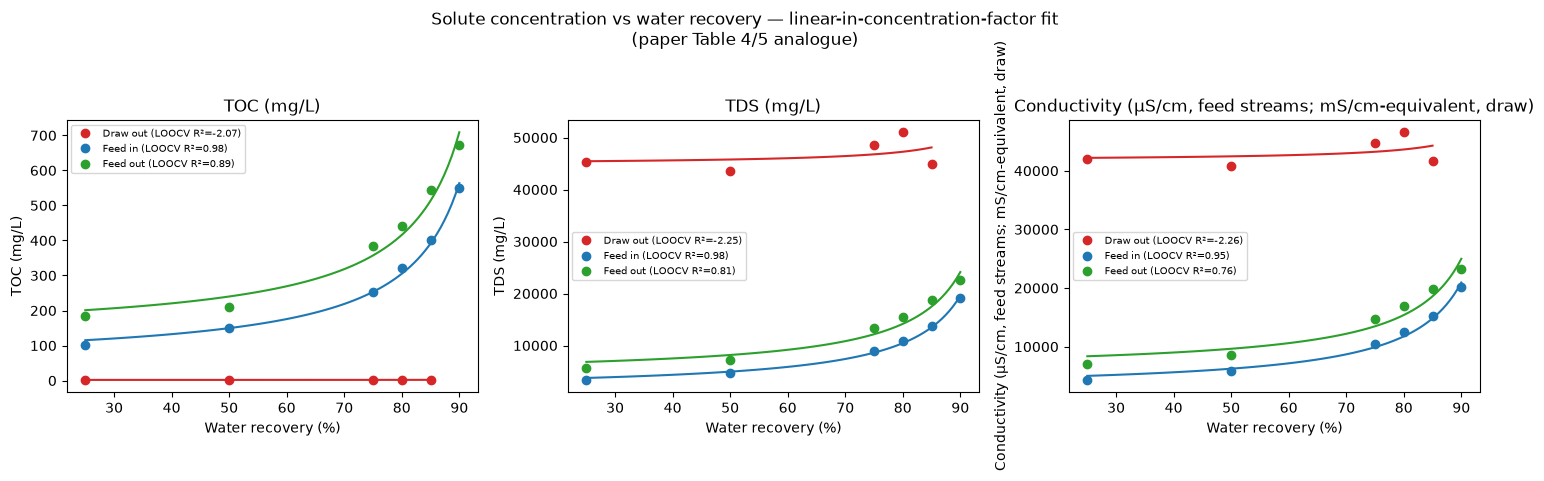

In [3]:
results = {}
fig, axes = plt.subplots(1,3, figsize=(15,4.5))
targets = ["TOC_mg_L","TDS_mg_L","conductivity_uS_cm"]
titles = ["TOC (mg/L)", "TDS (mg/L)", "Conductivity (\u00b5S/cm, feed streams; mS/cm-equivalent, draw)"]
colors = {"Feed in":"#1f77b4","Feed out":"#2ca02c","Draw out":"#d62728"}
for ax, target, title in zip(axes, targets, titles):
    for stream, g in df.groupby("stream"):
        g = g.sort_values("recovery_pct")
        X = g[["CF"]].values
        y = g[target].values
        if len(g) >= 4:
            loo = LeaveOneOut()
            model = LinearRegression()
            pred = cross_val_predict(model, X, y, cv=loo)
            r2 = r2_score(y, pred)
            results[(stream, target)] = r2
            model.fit(X, y)
            recovery_grid = np.linspace(g.recovery_pct.min(), g.recovery_pct.max(), 100)
            xg = (1/(1-recovery_grid/100)).reshape(-1,1)  # CF grid, same transform as X
            yg = model.predict(xg)
            ax.plot(recovery_grid, yg, "-", color=colors[stream])  # plot vs recovery%, not CF
            ax.plot(g.recovery_pct, y, "o", color=colors[stream], label=f"{stream} (LOOCV R\u00b2={r2:.2f})")
    ax.set_xlabel("Water recovery (%)")
    ax.set_ylabel(title)
    ax.legend(fontsize=7)
    ax.set_title(title)
plt.suptitle("Solute concentration vs water recovery \u2014 linear-in-concentration-factor fit\n(paper Table 4/5 analogue)")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("plots/model3_toc_tds_cond.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
fi = df[df.stream=="Feed in"].set_index("recovery_pct")
do = df[df.stream=="Draw out"].set_index("recovery_pct")
common = fi.index.intersection(do.index)
rej = pd.DataFrame({
    "recovery_pct": common,
    "TOC_feed_in": fi.loc[common,"TOC_mg_L"].values,
    "TOC_draw_out": do.loc[common,"TOC_mg_L"].values,
})
rej["TOC_rejection_pct"] = (1 - rej.TOC_draw_out/rej.TOC_feed_in)*100

In [5]:
with open("models/metrics_toc_rejection.txt","w") as f:
    f.write("LOOCV R2 per stream/target (linear regression on concentration factor CF=1/(1-recovery/100)):\n")
    for k,v in results.items():
        f.write(f"  {k}: R2={v:.3f}\n")
    f.write("\nDerived TOC rejection (1 - draw_out/feed_in) vs paper Table 4 TOC rejection:\n")
    f.write(rej.to_string(index=False))
    f.write("\n\nPaper Table 4 TOC rejection (%): 25%:99.3, 50%:99.7, 75%:99.1, 90%:99.9\n")
print(rej)
for k,v in results.items():
    print(k, round(v,3))

   recovery_pct  TOC_feed_in  TOC_draw_out  TOC_rejection_pct
0            25   102.630883      1.812987          98.233488
1            50   149.406622      1.621065          98.914998
2            75   251.973524      2.657211          98.945440
3            80   321.947114      2.250653          99.300925
4            85   402.045036      1.670083          99.584603
('Draw out', 'TOC_mg_L') -2.071
('Feed in', 'TOC_mg_L') 0.979
('Feed out', 'TOC_mg_L') 0.893
('Draw out', 'TDS_mg_L') -2.252
('Feed in', 'TDS_mg_L') 0.982
('Feed out', 'TDS_mg_L') 0.813
('Draw out', 'conductivity_uS_cm') -2.259
('Feed in', 'conductivity_uS_cm') 0.949
('Feed out', 'conductivity_uS_cm') 0.759
